In [170]:
import numpy as np
import pandas as pd
import globals.path as pth
import matplotlib.pyplot as plt
import nitools as nt
import nitools.spm as spm
from nitools.spm import spm_hrf
import nibabel as nb
import os

plt.style.use('default')

In [171]:
pinfo = pd.read_csv(os.path.join(pth.baseDir, 'participants.tsv'), sep='\t')
sn = 108
H = 'L'
roi = 'S1'
glm = 2

func_runs = pinfo.loc[pinfo.participant_id == f"subj{sn}", "FuncRuns_day3"].iloc[0].split('.')
func_runs = np.array(func_runs, dtype=int)
func_runs = np.array([func_runs + func_runs.size * i for i in range(3)]).flatten()
P = np.array(pinfo.loc[pinfo.participant_id == f"subj{sn}", f"P{glm}"].iloc[0].split(','), dtype=float)

path_glm = os.path.join(pth.baseDir, f'glm{glm}', f'subj{sn}')
path_hrf = os.path.join(pth.baseDir, 'hrf', f'subj{sn}')
events = pd.read_csv(os.path.join(pth.baseDir, pth.behavDir, 'day3', f'efc4_subj{sn}_glm{glm}_events.tsv'), sep='\t')
events = events[events.BN.isin(func_runs)]
TR = 1
nTR = 336
BN = events.BN.to_numpy() - 1
onset_b = events.Onset.to_numpy()
onset = (np.round(onset_b * TR) + BN * nTR).astype(int)
onset = np.sort(onset)
SPM = spm.SpmGlm(path_glm)
SPM.get_info_from_spm_mat()
y_raw = np.load(os.path.join(path_hrf, f'BOLD.ROI.{H}.{roi}.npy'))

[ 3. 12.  1.  1.  6.  0. 32.]


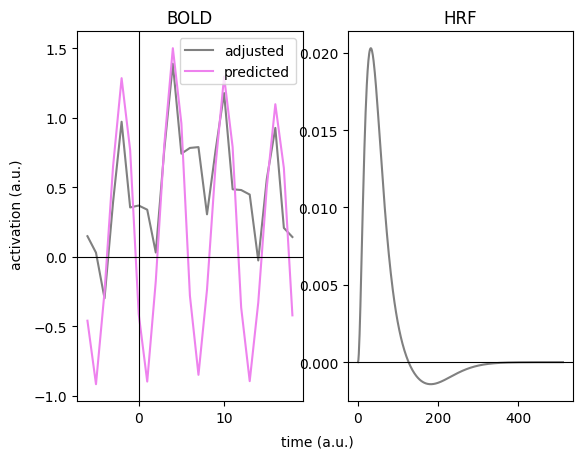

In [172]:
#P = [12, 24, 1, 1, 6, 0, 32]
hrf, p = spm_hrf(1, P=P)
SPM.convolve_glm(hrf)
y_scl = y_raw * SPM.gSF[:, None]  # rescale y_raw
_, info, data_filt, data_hat, data_adj, _ = SPM.rerun_glm(y_scl)
y_cut_filt = spm.cut(data_filt, pre=6, at=onset, post=18, padding='last').mean(axis=(0, -1)) #[onset > 3660 * 2]
y_cut_adj = spm.cut(data_adj, pre=6, at=onset, post=18, padding='last').mean(axis=(0, -1))
y_cut_hat = spm.cut(data_hat, pre=6, at=onset, post=18, padding='last').mean(axis=(0, -1))

fig, axs = plt.subplots(1, 2, )

tAx = np.linspace(-6, 18, 25)
axs[0].plot(tAx, y_cut_adj, color='grey', label='adjusted')
axs[0].plot(tAx, y_cut_hat, color='violet', label='predicted')
axs[0].axhline(0, color='k', lw=.8)
axs[0].axvline(0, color='k', lw=.8)
axs[0].set_title('BOLD')
axs[0].legend()
axs[1].plot(hrf, color='grey')
axs[1].axhline(0, color='k', lw=.8)
axs[1].set_title('HRF')

fig.supxlabel('time (a.u.)', fontsize=10)
fig.supylabel('activation (a.u.)', fontsize=10)

print(P)

plt.show()

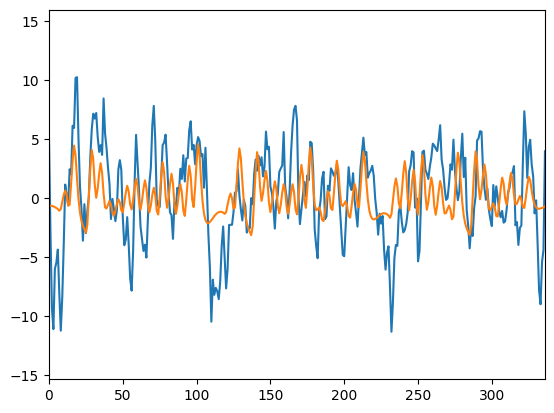

In [175]:
plt.plot(data_adj.mean(axis=-1))
plt.plot(data_hat.mean(axis=-1))
bl = 1
plt.xlim([0 + 336 * (bl -1), 336+ 336 * (bl -1)])
plt.show()

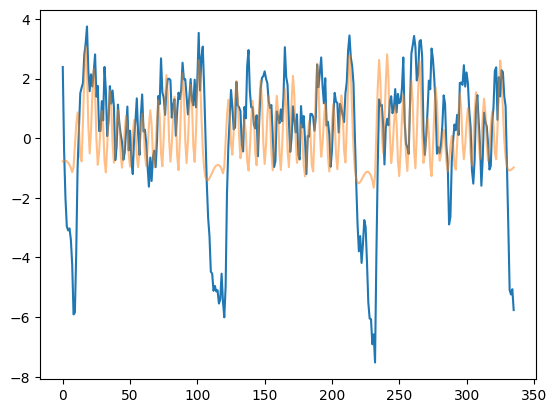

In [174]:
run_adj, run_hat = [], []
for bl in range(10):
    run_adj.append(data_adj.mean(axis=-1)[0 + 336 * (bl):336+ 336 * (bl)])
    run_hat.append(data_hat.mean(axis=-1)[0 + 336 * (bl):336+ 336 * (bl)])
run_adj, run_hat  = np.array(run_adj), np.array(run_hat)
plt.plot(run_adj.mean(axis=0))
plt.plot(run_hat.mean(axis=0), alpha=.5)